# Insurance Cost Prediction — Standardized ML Pipeline

Predict medical insurance **charges** (a regression problem) using a clean, leakage-free pipeline.

**Pipeline order:**
1. Basic Analysis
2. Train–Test Split (done early, before any learning from data)
3. EDA (on training data only)
4. Feature Engineering
5. Encoding (One-Hot for nominal categoricals)
6. Outlier Handling — compare IQR vs Z-score vs Winsorization, keep the best
7. Feature Scaling — compare Standard vs MinMax vs Robust, keep the best
8. Model Training & Comparison

> **Why split first?** Every transformation that *learns* from the data (outlier bounds, scaling ranges, encoding categories) is fit on the **training set only** and then applied to the test set. This prevents *data leakage* — the test set must stay completely unseen for an honest score.

## 0. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from scipy import stats
from scipy.stats.mstats import winsorize

sns.set()

## 1. Basic Analysis

Load the data and get a first feel for it: shape, column types, summary statistics, and missing values.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Study/Jhankar Mahbub/Phitron ML AI/Main course/ML without git/ML practice self/Machine Learning Projects/Regression/Insurance Cost Prediction/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print('Shape:', df.shape)
df.info()

Shape: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
# check for missing values
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## 2. Train–Test Split (done early to prevent data leakage)

split **before** EDA, feature engineering, encoding, outlier handling, and scaling. From here on, the test set is touched only for the final evaluation.

In [7]:
X = df.drop(columns='charges')
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (1070, 6) | Test: (268, 6)


## 3. EDA (training data only)

explore only the training set so that nothing about the test set influences our decisions.

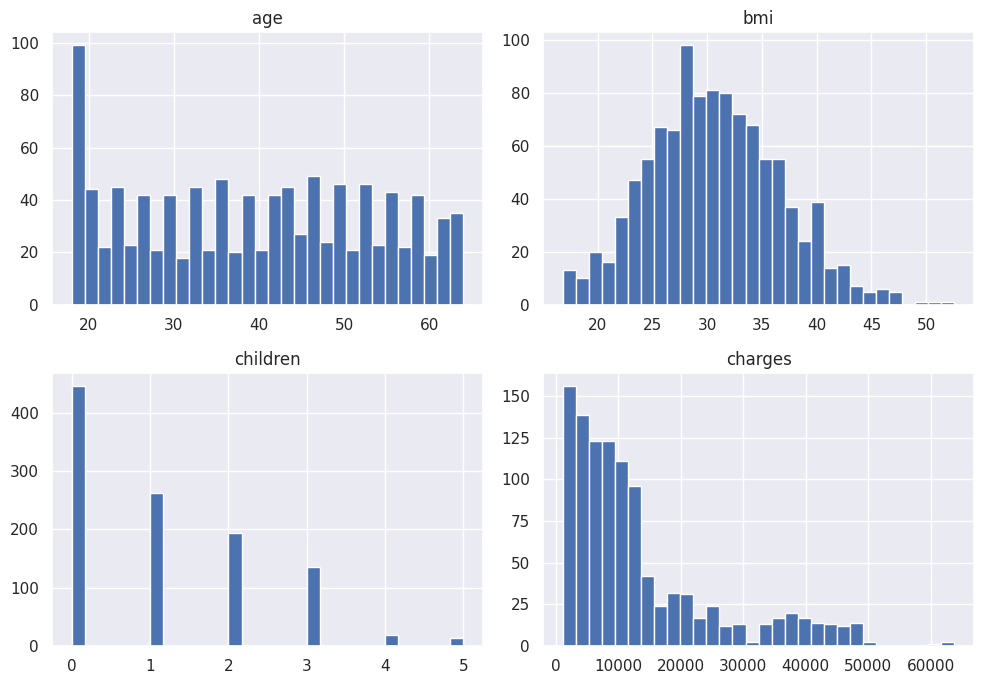

In [8]:
# put features + target back together for convenient exploration
train_df = X_train.copy()
train_df['charges'] = y_train

# distribution of the numeric columns
num_cols = ['age', 'bmi', 'children', 'charges']
train_df[num_cols].hist(figsize=(10, 7), bins=30)
plt.tight_layout()
plt.show()

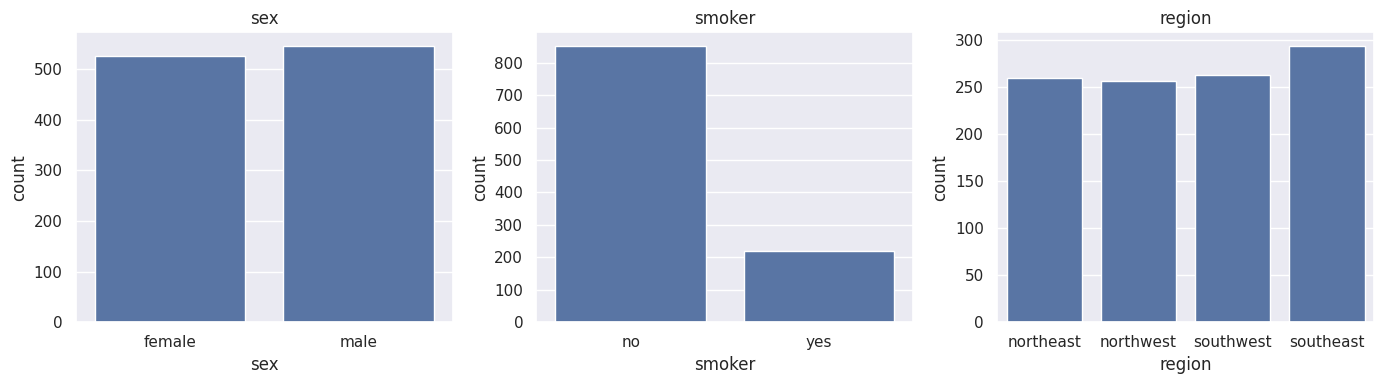

In [9]:
# distribution of the categorical columns
cat_cols = ['sex', 'smoker', 'region']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cat_cols):
    sns.countplot(x=col, data=train_df, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

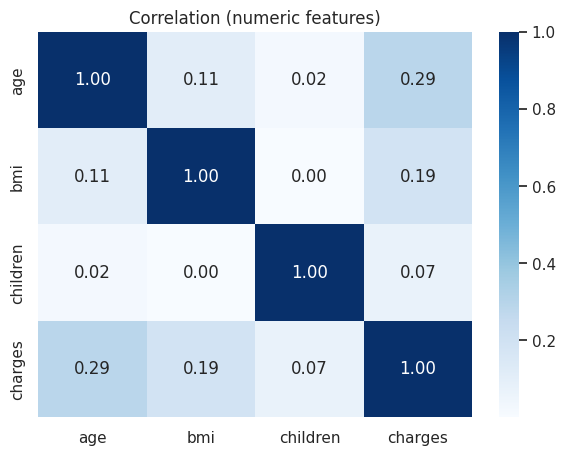

In [10]:
# correlation between numeric features
plt.figure(figsize=(7, 5))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation (numeric features)')
plt.show()

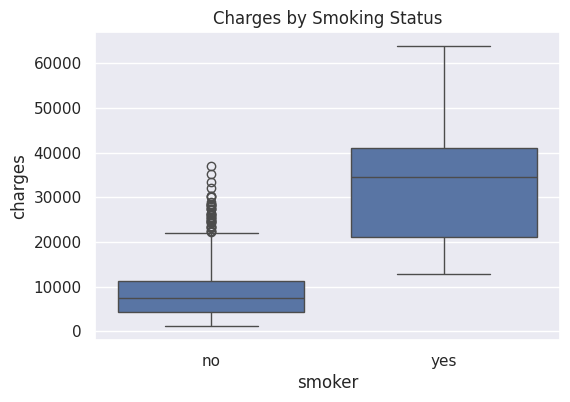

In [11]:
# key insight: smoking is the biggest driver of charges
plt.figure(figsize=(6, 4))
sns.boxplot(x='smoker', y='charges', data=train_df)
plt.title('Charges by Smoking Status')
plt.show()

## 4. Feature Engineering

define a function so the **exact same** transformation is applied to train and test. These rules are row-wise (no information shared across rows), so there is no leakage.

In [12]:
def add_features(data):
    data = data.copy()
    # obese flag (BMI >= 30 is the medical obesity threshold)
    data['is_obese'] = (data['bmi'] >= 30).astype(int)
    # high-risk = obese AND smoker (this combination drives costs up sharply)
    data['high_risk_smoker'] = (((data['bmi'] >= 30) & (data['smoker'] == 'yes'))).astype(int)
    return data

X_train = add_features(X_train)
X_test = add_features(X_test)
X_train.head()

,age,sex,bmi,children,smoker,region,is_obese,high_risk_smoker
882,21,female,22.135,0,no,northeast,0,0
505,37,male,30.875,3,no,northwest,1,0
798,58,female,33.100,0,no,southwest,1,0
792,22,female,23.180,0,no,northeast,0,0
201,48,female,32.230,1,no,southeast,1,0


## 5. Encoding (One-Hot for nominal categoricals)

`sex`, `smoker`, and `region` are **nominal** (no natural order), so we one-hot encode them. We encode train and test separately, then align the test columns to the training columns so both have identical features.

In [13]:
cat_cols = ['sex', 'smoker', 'region']

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# make sure test has exactly the same columns (and order) as train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# cast everything to float (dummies come out as bool)
X_train = X_train.astype(float)
X_test = X_test.astype(float)
X_train.head()

,age,bmi,children,is_obese,high_risk_smoker,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
882,21.0,22.135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
505,37.0,30.875,3.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
798,58.0,33.100,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
792,22.0,23.180,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
201,48.0,32.230,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## 6. Outlier Handling — IQR vs Z-score vs Winsorization

Outliers are detected on the **continuous** numeric columns only. We try three methods, score each with cross-validation on the training set, and keep whichever performs best (including doing nothing).

- **IQR**: drop rows outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- **Z-score**: drop rows with `|z| > 3`.
- **Winsorization**: cap extreme values at the 5th/95th percentiles (no rows removed).

All handling is applied to the **training set only**.

In [14]:
outlier_cols = ['age', 'bmi']  # continuous columns (children is a small count, dummies are 0/1)

def cv_score(Xc, yc):
    model = RandomForestRegressor(n_estimators=100, random_state=2)
    return cross_val_score(model, Xc, yc, cv=5, scoring='r2').mean()

def iqr_clean(X, y, cols):
    mask = pd.Series(True, index=X.index)
    for c in cols:
        q1, q3 = X[c].quantile(0.25), X[c].quantile(0.75)
        iqr = q3 - q1
        mask &= X[c].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    return X[mask], y[mask]

def zscore_clean(X, y, cols):
    z = np.abs(stats.zscore(X[cols]))
    mask = (z < 3).all(axis=1)
    return X[mask], y[mask]

def winsor_clean(X, y, cols, limit=0.05):
    Xw = X.copy()
    for c in cols:
        Xw[c] = np.asarray(winsorize(Xw[c], limits=[limit, limit]))
    return Xw, y

scores = {}
scores['none'] = cv_score(X_train, y_train)
scores['iqr'] = cv_score(*iqr_clean(X_train, y_train, outlier_cols))
scores['zscore'] = cv_score(*zscore_clean(X_train, y_train, outlier_cols))
scores['winsorize'] = cv_score(*winsor_clean(X_train, y_train, outlier_cols))

for k, v in scores.items():
    print(f'{k:10s} CV R2: {v:.4f}')

best_outlier = max(scores, key=scores.get)
print('\nBest outlier method:', best_outlier)

none       CV R2: 0.8252
iqr        CV R2: 0.8225
zscore     CV R2: 0.8265
winsorize  CV R2: 0.8263

Best outlier method: zscore


In [15]:
# apply the winning method to the training set
if best_outlier == 'iqr':
    X_train, y_train = iqr_clean(X_train, y_train, outlier_cols)
elif best_outlier == 'zscore':
    X_train, y_train = zscore_clean(X_train, y_train, outlier_cols)
elif best_outlier == 'winsorize':
    X_train, y_train = winsor_clean(X_train, y_train, outlier_cols)
# 'none' -> leave training data unchanged

print('Training rows after outlier handling:', X_train.shape[0])

Training rows after outlier handling: 1067


## 7. Feature Scaling — Standard vs MinMax vs Robust

We fit each scaler on the training set, then score with a **scale-sensitive** model (KNN) to decide which scaler is best. The chosen scaler is then fit on train and applied to both train and test.

> Note: tree models (Random Forest, Gradient Boosting) and Linear Regression are essentially scale-invariant for R² — scaling mainly matters for distance/gradient based models like KNN. That is why we judge the scaler with KNN.

In [16]:
scalers = {
    'standard': StandardScaler(),
    'minmax': MinMaxScaler(),
    'robust': RobustScaler(),
}

scaler_scores = {}
for name, sc in scalers.items():
    X_scaled = sc.fit_transform(X_train)
    scaler_scores[name] = cross_val_score(KNeighborsRegressor(), X_scaled, y_train, cv=5, scoring='r2').mean()
    print(f'{name:10s} CV R2 (KNN): {scaler_scores[name]:.4f}')

best_scaler_name = max(scaler_scores, key=scaler_scores.get)
print('\nBest scaler:', best_scaler_name)

scaler = scalers[best_scaler_name]
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

standard   CV R2 (KNN): 0.8176
minmax     CV R2 (KNN): 0.8111
robust     CV R2 (KNN): 0.8155

Best scaler: standard


## 8. Model Training & Comparison

Train several regression models on the prepared data and compare them on the untouched test set using R², MAE, and RMSE.

In [17]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=2),
    'Gradient Boosting': GradientBoostingRegressor(random_state=2),
    'KNN': KNeighborsRegressor(),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'R2': r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    })

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df

,Model,R2,MAE,RMSE
0,Gradient Boosting,0.868269,2356.424732,4447.855295
1,Linear Regression,0.866651,2349.303094,4475.092067
2,KNN,0.839596,2809.920487,4908.115783
3,Random Forest,0.838236,2723.352128,4928.872741


In [18]:
best_row = results_df.iloc[0]
print('Best model :', best_row['Model'])
print('Test R2    :', round(best_row['R2'], 4))
print('Test MAE   :', round(best_row['MAE'], 2))
print('Test RMSE  :', round(best_row['RMSE'], 2))

Best model : Gradient Boosting
Test R2    : 0.8683
Test MAE   : 2356.42
Test RMSE  : 4447.86


## Summary

- Split **first**, then fit every data-driven step on the training set only — no leakage.
- Outlier method and scaler were **chosen by cross-validation**, not guessed.
- Models compared on a clean test set with R², MAE, and RMSE.